# AMERS v4 — Model Testing & Live Demo

**Standalone notebook** for testing the trained v4 model.

- Loads all trained checkpoints from Google Drive
- Picks random test samples and shows predictions with confidence
- Generates bar charts, confusion matrix, and per-class stats

**Prerequisites:** Run the full training pipeline in `00_setup_and_run.ipynb` first.

## 1. Setup — Mount Drive, Clone Repo, Fix Dependencies

In [54]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  SETUP — Mount Drive, clone repo, fix numpy/scipy if needed   ║
# ╚══════════════════════════════════════════════════════════════════╝
import os, shutil, subprocess
from pathlib import Path

# ── Robust Drive mount: verify it's truly accessible ──
from google.colab import drive

drive_ok = False
try:
    if os.path.exists('/content/drive/MyDrive'):
        os.listdir('/content/drive/MyDrive')
        drive_ok = True
        print('Drive already mounted and accessible ✅')
except OSError:
    pass

if not drive_ok:
    # Clean up stale/broken mount before re-mounting
    print('Drive not accessible — cleaning up and mounting...')
    subprocess.run(['fusermount', '-u', '/content/drive'],
                   capture_output=True, timeout=10)
    if os.path.exists('/content/drive'):
        shutil.rmtree('/content/drive', ignore_errors=True)
    drive.mount('/content/drive')
    print('Drive mounted ✅')

# Clone or pull repo
REPO_DIR = '/content/amers'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/RAVINDRA8008/MAJORDRAFT.git {REPO_DIR}
    print('Repository cloned.')
else:
    !git -C {REPO_DIR} pull --ff-only
    print('Repository updated.')

os.chdir(REPO_DIR)

# Fix numpy/scipy compatibility (Colab sometimes has mismatched versions)
print('\nFixing numpy/scipy compatibility...')
!pip install -q --upgrade numpy scipy scikit-learn 2>&1 | tail -3

# Install project deps
!pip install -q -r requirements.txt 2>&1 | tail -3
print('\n✅ Dependencies ready.')

# Verify
import numpy as np
import torch
print(f'NumPy {np.__version__}, PyTorch {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️ No GPU — will run on CPU (slower but works)')

Drive already mounted and accessible ✅
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 194.83 KiB | 11.46 MiB/s, done.
From https://github.com/RAVINDRA8008/MAJORDRAFT
   5981e2f..6c52272  main       -> origin/main
Updating 5981e2f..6c52272
Fast-forward
 notebooks/07_test_demo.ipynb | 277 +++++++++++++++++++++++++++++++++++++------
 1 file changed, 243 insertions(+), 34 deletions(-)
Repository updated.

Fixing numpy/scipy compatibility...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.
opencv-contrib-p

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  DOWNLOAD CHECKPOINTS via Google Drive API (authenticated)   ║
# ║  Uses your Colab auth — no public sharing needed             ║
# ║  Step 1: Verify file IDs match expected names                ║
# ║  Step 2: Download to local /content/checkpoints/             ║
# ╚══════════════════════════════════════════════════════════════════╝
import os, io
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
from google.colab import auth

auth.authenticate_user()
drive_service = build('drive', 'v3')

LOCAL_CKPT = '/content/checkpoints'  # local fast path

# Google Drive file IDs → local paths
FILES = {
    '1sQtw7Om8s_veY6SzOHGPv4Q6qjVUGAHi': f'{LOCAL_CKPT}/v3/eeg_encoder_contrastive.pt',
    '1lY4L0gZDFlk2zHYezYEvZHecmCmoMBvI': f'{LOCAL_CKPT}/v3/speech_encoder_contrastive.pt',
    '1NDkyw21q2V_luvO-8X3zqEHqw-s52IY-': f'{LOCAL_CKPT}/v3/eeg_encoder_dann.pt',
    '1D4p3p_tKKss2znA5e8JHJ0tgw7I3h0pc': f'{LOCAL_CKPT}/v3/speech_encoder_dann.pt',
    '1hzU6fMF1FOPe1iVUiS8YY9LrwwL-0swG': f'{LOCAL_CKPT}/v3/best_transformer_fusion.pt',
    '1Dn44orMmVHQxQKPfWOBslWUEgktB8F1c': f'{LOCAL_CKPT}/gan/gan_final.pt',
    '1u0R_okolItQlIgx3Xp3U6uyrr9UW7RI8': f'{LOCAL_CKPT}/speech/speech_encoder_final.pt',
    '14xKckanol4h1JUIEM16geS8uJF8cDins': f'{LOCAL_CKPT}/eeg/eeg_encoder_final.pt',
}

# ── Step 1: Verify each file ID matches expected name ──
print('🔍 Verifying file IDs against Drive...\n')
id_ok = True
for file_id, dest in FILES.items():
    expected_name = os.path.basename(dest)
    try:
        meta = drive_service.files().get(fileId=file_id, fields='name,size').execute()
        real_name = meta['name']
        real_sz = int(meta.get('size', 0)) / (1024*1024)
        match = '✅' if real_name == expected_name else '❌ MISMATCH!'
        if real_name != expected_name:
            id_ok = False
        print(f'  {match} ID ...{file_id[-8:]} → Drive: "{real_name}" ({real_sz:.1f} MB)  expected: "{expected_name}"')
    except Exception as e:
        print(f'  ❌ ID ...{file_id[-8:]} → ERROR: {e}')
        id_ok = False

if not id_ok:
    print('\n⚠️  FILE ID MISMATCHES DETECTED — fix the IDs above before proceeding!')
else:
    print('\n✅ All file IDs verified — names match.')

# ── Step 2: Download ──
print('\nDownloading checkpoints...\n')
downloaded, skipped = 0, 0
for file_id, dest in FILES.items():
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    if os.path.exists(dest) and os.path.getsize(dest) > 1000:
        print(f'  ✅ Already exists: {os.path.basename(dest)}')
        skipped += 1
    else:
        fname = os.path.basename(dest)
        print(f'  ⬇️  Downloading: {fname}...', end=' ')
        try:
            request = drive_service.files().get_media(fileId=file_id)
            with open(dest, 'wb') as f:
                downloader = MediaIoBaseDownload(f, request)
                done = False
                while not done:
                    _, done = downloader.next_chunk()
            sz = os.path.getsize(dest) / (1024*1024)
            print(f'✅ ({sz:.1f} MB)')
            downloaded += 1
        except Exception as e:
            print(f'❌ {e}')

print(f'\n✅ {downloaded} downloaded, {skipped} already existed')
print(f'📁 Checkpoints at: {LOCAL_CKPT}')

🔍 Verifying file IDs against Drive...



  ✅ ID ...qjVUGAHi → Drive: "eeg_encoder_contrastive.pt" (9.5 MB)  expected: "eeg_encoder_contrastive.pt"
  ✅ ID ...mCmoMBvI → Drive: "speech_encoder_contrastive.pt" (11.2 MB)  expected: "speech_encoder_contrastive.pt"
  ❌ MISMATCH! ID ...w7I3h0pc → Drive: "speech_encoder_dann.pt" (11.2 MB)  expected: "eeg_encoder_dann.pt"
  ❌ MISMATCH! ID ...w-s52IY- → Drive: "eeg_encoder_dann.pt" (9.5 MB)  expected: "speech_encoder_dann.pt"
  ✅ ID ...wwL-0swG → Drive: "best_transformer_fusion.pt" (1.2 MB)  expected: "best_transformer_fusion.pt"
  ✅ ID ...gktB8F1c → Drive: "gan_final.pt" (7.2 MB)  expected: "gan_final.pt"
  ✅ ID ...r9UW7RI8 → Drive: "speech_encoder_final.pt" (11.2 MB)  expected: "speech_encoder_final.pt"
  ✅ ID ...JF8cDins → Drive: "eeg_encoder_final.pt" (9.5 MB)  expected: "eeg_encoder_final.pt"

⚠️  FILE ID MISMATCHES DETECTED — fix the IDs above before proceeding!


  ✅ Already exists: eeg_encoder_contrastive.pt
  ✅ Already exists: speech_encoder_contrastive.pt
  ✅ Already exists: 

In [56]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  DOWNLOAD PROCESSED DATA via Google Drive API                ║
# ║  DEAP (32 subjects) + IEMOCAP (5 sessions) → local cache    ║
# ║  get_paths() will auto-detect /content/local_data/           ║
# ╚══════════════════════════════════════════════════════════════════╝
import os, io
from googleapiclient.http import MediaIoBaseDownload

LOCAL_DATA = '/content/local_data'

def find_folder(service, name, parent_id='root'):
    """Find a Drive folder by name under a parent folder."""
    q = (f"name='{name}' and '{parent_id}' in parents "
         f"and mimeType='application/vnd.google-apps.folder' and trashed=false")
    res = service.files().list(q=q, fields='files(id,name)').execute()
    files = res.get('files', [])
    return files[0]['id'] if files else None

def list_files_in_folder(service, folder_id, ext='.npy'):
    """List all files with given extension in a Drive folder."""
    q = f"'{folder_id}' in parents and trashed=false"
    all_files = []
    page_token = None
    while True:
        res = service.files().list(
            q=q, fields='nextPageToken, files(id,name,size)',
            pageSize=100, pageToken=page_token
        ).execute()
        all_files.extend(res.get('files', []))
        page_token = res.get('nextPageToken')
        if not page_token:
            break
    return [f for f in all_files if f['name'].endswith(ext)]

def download_file(service, file_id, dest_path):
    """Download a single file from Drive to local path."""
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)
    request = service.files().get_media(fileId=file_id)
    with open(dest_path, 'wb') as f:
        downloader = MediaIoBaseDownload(f, request)
        done = False
        while not done:
            _, done = downloader.next_chunk()

# ── Navigate Drive folder hierarchy ──
print('🔍 Locating processed data on Google Drive...\n')
amers_id = find_folder(drive_service, 'AMERS')
if not amers_id:
    raise RuntimeError("Cannot find 'AMERS' folder on Drive")

data_id = find_folder(drive_service, 'data', amers_id)
if not data_id:
    raise RuntimeError("Cannot find 'AMERS/data' folder on Drive")

# ── DEAP processed data ──
deap_id = find_folder(drive_service, 'deap', data_id)
deap_proc_id = find_folder(drive_service, 'processed', deap_id) if deap_id else None

if deap_proc_id:
    deap_files = list_files_in_folder(drive_service, deap_proc_id)
    deap_dest = f'{LOCAL_DATA}/deap/processed'
    os.makedirs(deap_dest, exist_ok=True)

    existing = [f for f in deap_files
                if os.path.exists(f'{deap_dest}/{f["name"]}')
                and os.path.getsize(f'{deap_dest}/{f["name"]}') > 100]

    to_download = [f for f in deap_files if f not in existing]
    print(f'DEAP: {len(deap_files)} files found, '
          f'{len(existing)} cached, {len(to_download)} to download')

    for i, f in enumerate(to_download, 1):
        dest = f'{deap_dest}/{f["name"]}'
        sz_mb = int(f.get("size", 0)) / (1024*1024)
        print(f'  ⬇️  [{i}/{len(to_download)}] {f["name"]} ({sz_mb:.1f} MB)...', end=' ')
        download_file(drive_service, f['id'], dest)
        print('✅')
    print(f'  📁 DEAP data at: {deap_dest}')
else:
    print('⚠️ DEAP processed folder not found on Drive')

# ── IEMOCAP processed data ──
iemocap_id = find_folder(drive_service, 'iemocap', data_id)
iemocap_proc_id = find_folder(drive_service, 'processed', iemocap_id) if iemocap_id else None

if iemocap_proc_id:
    # Also check for a features/ subfolder (IEMOCAPLoader searches there)
    features_sub_id = find_folder(drive_service, 'features', iemocap_proc_id)
    search_id = features_sub_id if features_sub_id else iemocap_proc_id

    iem_files = list_files_in_folder(drive_service, search_id)
    # Also grab from parent if features subfolder was used
    if features_sub_id:
        iem_files += list_files_in_folder(drive_service, iemocap_proc_id)

    # Deduplicate
    seen = set()
    unique_files = []
    for f in iem_files:
        if f['name'] not in seen:
            seen.add(f['name'])
            unique_files.append(f)
    iem_files = unique_files

    # Download to matching subfolder structure
    if features_sub_id:
        iem_dest = f'{LOCAL_DATA}/iemocap/processed/features'
    else:
        iem_dest = f'{LOCAL_DATA}/iemocap/processed'
    os.makedirs(iem_dest, exist_ok=True)

    existing = [f for f in iem_files
                if os.path.exists(f'{iem_dest}/{f["name"]}')
                and os.path.getsize(f'{iem_dest}/{f["name"]}') > 100]

    to_download = [f for f in iem_files if f not in existing]
    print(f'\nIEMOCAP: {len(iem_files)} files found, '
          f'{len(existing)} cached, {len(to_download)} to download')

    for i, f in enumerate(to_download, 1):
        dest = f'{iem_dest}/{f["name"]}'
        sz_mb = int(f.get("size", 0)) / (1024*1024)
        print(f'  ⬇️  [{i}/{len(to_download)}] {f["name"]} ({sz_mb:.1f} MB)...', end=' ')
        download_file(drive_service, f['id'], dest)
        print('✅')
    print(f'  📁 IEMOCAP data at: {iem_dest}')
else:
    print('⚠️ IEMOCAP processed folder not found on Drive')

print(f'\n✅ Processed data ready at {LOCAL_DATA}/')
print('   get_paths() will auto-detect this local cache.')

🔍 Locating processed data on Google Drive...

DEAP: 64 files found, 64 cached, 0 to download
  📁 DEAP data at: /content/local_data/deap/processed

IEMOCAP: 10 files found, 10 cached, 0 to download
  📁 IEMOCAP data at: /content/local_data/iemocap/processed

✅ Processed data ready at /content/local_data/
   get_paths() will auto-detect this local cache.


## 2. Verify Checkpoints Exist

In [57]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CHECK: Are all required checkpoints available + valid?       ║
# ║  Also inspect checkpoint contents (keys, shapes) for sanity  ║
# ╚══════════════════════════════════════════════════════════════════╝
import torch
from pathlib import Path

CKPT = Path('/content/checkpoints')

required = {
    'EEG Encoder (v2)':      'eeg/eeg_encoder_final.pt',
    'Speech Encoder (v2)':   'speech/speech_encoder_final.pt',
    'GAN (WGAN-GP)':         'gan/gan_final.pt',
    'EEG Contrastive (v3)':  'v3/eeg_encoder_contrastive.pt',
    'Speech Contrastive (v3)':'v3/speech_encoder_contrastive.pt',
    'EEG DANN (v3)':         'v3/eeg_encoder_dann.pt',
    'Speech DANN (v3)':      'v3/speech_encoder_dann.pt',
    'Transformer Fusion':    'v3/best_transformer_fusion.pt',
}

print('Checkpoint Status + Content Inspection:')
print('=' * 80)
all_ok = True
for label, path in required.items():
    p = CKPT / path
    if p.exists():
        sz = p.stat().st_size / 1024
        try:
            sd = torch.load(p, map_location='cpu', weights_only=False)
            if isinstance(sd, dict):
                # Check if it's a wrapped checkpoint or bare state_dict
                non_tensor_keys = [k for k in sd.keys() if not isinstance(sd[k], torch.Tensor)]
                tensor_keys = [k for k in sd.keys() if isinstance(sd[k], torch.Tensor)]
                if non_tensor_keys and not tensor_keys:
                    # Wrapped checkpoint like {"fusion": state_dict, "epoch": int}
                    inner_keys = list(sd.keys())
                    print(f'  ✅ {label:30s} ({sz:.0f} KB) — dict keys: {inner_keys}')
                    if 'fusion' in sd:
                        fusion_sd = sd['fusion']
                        n_params = sum(v.numel() for v in fusion_sd.values())
                        print(f'     └─ fusion state_dict: {len(fusion_sd)} layers, {n_params:,} params')
                else:
                    # Bare state_dict
                    n_params = sum(v.numel() for v in sd.values() if isinstance(v, torch.Tensor))
                    n_layers = sum(1 for v in sd.values() if isinstance(v, torch.Tensor))
                    sample_key = next((k for k in sd.keys() if isinstance(sd[k], torch.Tensor)), None)
                    sample_shape = sd[sample_key].shape if sample_key else '?'
                    print(f'  ✅ {label:30s} ({sz:.0f} KB) — {n_layers} layers, {n_params:,} params, e.g. {sample_key}: {sample_shape}')
            else:
                print(f'  ⚠️ {label:30s} ({sz:.0f} KB) — unexpected type: {type(sd).__name__}')
        except Exception as e:
            print(f'  ⚠️ {label:30s} ({sz:.0f} KB) — load error: {e}')
    else:
        print(f'  ❌ {label:30s} — MISSING')
        all_ok = False
print('=' * 80)

if all_ok:
    print('\n✅ All checkpoints found — ready to test!')
else:
    print('\n⚠️ Some checkpoints missing.')
    print('  Re-run the download cell above.')

Checkpoint Status + Content Inspection:
  ✅ EEG Encoder (v2)               (9771 KB) — 59 layers, 2,495,873 params, e.g. cls_token: torch.Size([1, 1, 256])
  ✅ Speech Encoder (v2)            (11477 KB) — 52 layers, 2,934,531 params, e.g. attn_query: torch.Size([1, 1, 256])
  ✅ GAN (WGAN-GP)                  (7422 KB) — dict keys: ['generator', 'discriminator', 'opt_g', 'opt_d']
  ✅ EEG Contrastive (v3)           (9771 KB) — 59 layers, 2,495,873 params, e.g. cls_token: torch.Size([1, 1, 256])
  ✅ Speech Contrastive (v3)        (11478 KB) — 52 layers, 2,934,531 params, e.g. attn_query: torch.Size([1, 1, 256])
  ✅ EEG DANN (v3)                  (11477 KB) — 52 layers, 2,934,531 params, e.g. attn_query: torch.Size([1, 1, 256])
  ✅ Speech DANN (v3)               (9771 KB) — 59 layers, 2,495,873 params, e.g. cls_token: torch.Size([1, 1, 256])
  ✅ Transformer Fusion             (1192 KB) — dict keys: ['fusion', 'val_acc', 'epoch']
     └─ fusion state_dict: 94 layers, 296,132 params

✅ All ch

## 3. Load Trained Models

In [58]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  LOAD ALL TRAINED v4 MODELS                                  ║
# ╚══════════════════════════════════════════════════════════════════╝
import sys, torch
from pathlib import Path

sys.path.insert(0, '/content/amers')

from src.utils.config import load_config
from src.utils.seed import set_seed
from src.utils.paths import get_paths
from src.utils.device import get_device
from src.models.eeg_encoder import EEGEncoder
from src.models.speech_encoder import SpeechEncoder
from src.models.transformer_fusion import TransformerFusionClassifier

cfg = load_config('config/default.yaml')
set_seed(cfg.seed)
paths = get_paths(cfg)
device = get_device()

# Use local checkpoint dir (downloaded via Drive API)
ckpt = Path('/content/checkpoints')

LABEL_NAMES = ['Angry', 'Happy', 'Sad', 'Neutral']
LABEL_EMOJI = ['😠', '😊', '😢', '😐']

print('Loading trained v4 models...\n')

# ── EEG Encoder ──
ecfg = cfg.model.eeg_encoder
eeg_enc = EEGEncoder(
    input_dim=ecfg.input_dim,
    hidden_dims=list(ecfg.hidden_dims),
    embedding_dim=ecfg.embedding_dim,
    dropout=ecfg.dropout,
).to(device)
eeg_source = 'random'
for name in ['v3/eeg_encoder_dann.pt', 'v3/eeg_encoder_contrastive.pt', 'eeg/eeg_encoder_final.pt']:
    if (ckpt / name).exists():
        try:
            eeg_enc.load_state_dict(torch.load(ckpt / name, map_location=device, weights_only=False))
            eeg_source = name
            print(f'  ✅ EEG encoder  ← {name}')
            break
        except RuntimeError as e:
            print(f'  ⚠️ EEG encoder  ✗ {name}: {e}')
            continue
eeg_enc.eval()

# ── Speech Encoder ──
scfg = cfg.model.speech_encoder
speech_enc = SpeechEncoder(
    n_features=scfg.n_mfcc,
    embedding_dim=scfg.embedding_dim,
).to(device)
sp_source = 'random'
for name in ['v3/speech_encoder_dann.pt', 'v3/speech_encoder_contrastive.pt', 'speech/speech_encoder_final.pt']:
    if (ckpt / name).exists():
        try:
            speech_enc.load_state_dict(torch.load(ckpt / name, map_location=device, weights_only=False))
            sp_source = name
            print(f'  ✅ Speech enc   ← {name}')
            break
        except RuntimeError as e:
            print(f'  ⚠️ Speech enc   ✗ {name}: {e}')
            continue
speech_enc.eval()

# ── Transformer Fusion ──
v3 = getattr(cfg, 'v3', {})
tf = v3.get('transformer_fusion', {}) if isinstance(v3, dict) else getattr(v3, 'transformer_fusion', {})
_g = lambda d, k, default: d.get(k, default) if isinstance(d, dict) else getattr(d, k, default)

fusion = TransformerFusionClassifier(
    eeg_embed_dim=ecfg.embedding_dim,
    speech_embed_dim=scfg.embedding_dim,
    n_tokens=_g(tf, 'n_tokens', 8),
    d_model=_g(tf, 'd_model', 64),
    n_heads=_g(tf, 'n_heads', 4),
    n_layers=_g(tf, 'n_layers', 2),
    num_classes=cfg.model.num_classes,
    dropout=0.0,
    modality_dropout_prob=0.0,
).to(device)
fusion_source = 'random'
for name in ['v3/best_transformer_fusion.pt', 'v3/best_fusion_v3.pt']:
    if (ckpt / name).exists():
        try:
            sd = torch.load(ckpt / name, map_location=device, weights_only=False)
            fusion.load_state_dict(sd.get('fusion', sd))
            fusion_source = name
            print(f'  ✅ Fusion       ← {name}')
            break
        except RuntimeError as e:
            print(f'  ⚠️ Fusion       ✗ {name}: {e}')
            continue
fusion.eval()

# ── Summary ──
print(f'\n{"─"*50}')
print(f'  EEG encoder : {eeg_source}')
print(f'  Speech enc  : {sp_source}')
print(f'  Fusion      : {fusion_source}')
print(f'{"─"*50}')

if 'random' in (eeg_source, sp_source, fusion_source):
    print('\n⚠️  WARNING: Some models using RANDOM weights!')
    print('  This means checkpoint loading FAILED → expect ~25% accuracy.')
    print('  Check: are the file IDs correct? Do shapes match?')
else:
    print(f'\n✅ All models loaded on {device}')

Loading trained v4 models...

  ⚠️ EEG encoder  ✗ v3/eeg_encoder_dann.pt: Error(s) in loading state_dict for EEGEncoder:
	Missing key(s) in state_dict: "cls_token", "pos_encoding", "channel_proj.0.weight", "channel_proj.0.bias", "channel_proj.1.weight", "channel_proj.1.bias", "channel_proj.4.weight", "channel_proj.4.bias", "channel_proj.5.weight", "channel_proj.5.bias", "attn_layers.0.attn.in_proj_weight", "attn_layers.0.attn.in_proj_bias", "attn_layers.0.attn.out_proj.weight", "attn_layers.0.attn.out_proj.bias", "attn_layers.0.norm1.weight", "attn_layers.0.norm1.bias", "attn_layers.0.norm2.weight", "attn_layers.0.norm2.bias", "attn_layers.0.ff.0.weight", "attn_layers.0.ff.0.bias", "attn_layers.0.ff.3.weight", "attn_layers.0.ff.3.bias", "attn_layers.1.attn.in_proj_weight", "attn_layers.1.attn.in_proj_bias", "attn_layers.1.attn.out_proj.weight", "attn_layers.1.attn.out_proj.bias", "attn_layers.1.norm1.weight", "attn_layers.1.norm1.bias", "attn_layers.1.norm2.weight", "attn_layers.1.norm

## 4. Load & Prepare Test Data

In [59]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  LOAD TEST DATA — DEAP (EEG) + IEMOCAP (Speech)              ║
# ║  Split with same seed as training → true held-out test set    ║
# ╚══════════════════════════════════════════════════════════════════╝
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from src.data.deap_loader import DEAPLoader
from src.data.iemocap_loader import IEMOCAPLoader
from src.utils.paths import get_paths

# Re-compute paths to pick up /content/local_data/ cache
paths = get_paths(cfg)
print(f'Data paths:')
print(f'  DEAP:    {paths["deap_processed"]}')
print(f'  IEMOCAP: {paths["iemocap_processed"]}')

# Load raw features
deap = DEAPLoader(processed_dir=paths['deap_processed'])
eeg_feat, eeg_lbl, _ = deap.load_all(flatten=True)
iemocap = IEMOCAPLoader(processed_dir=paths['iemocap_processed'])
sp_feat, sp_lbl, _ = iemocap.load_all()

print(f'\nDEAP:    {len(eeg_feat)} samples, {eeg_feat.shape[1]}-dim features')
print(f'IEMOCAP: {len(sp_feat)} samples, {sp_feat.shape[1:]}-dim features')

# Same split as training (seed-locked)
_, eeg_Xv, _, eeg_yv = train_test_split(
    eeg_feat, eeg_lbl, test_size=0.2, stratify=eeg_lbl, random_state=cfg.seed)
_, sp_Xv, _, sp_yv = train_test_split(
    sp_feat, sp_lbl, test_size=0.2, stratify=sp_lbl, random_state=cfg.seed)

print(f'\nTest split: {len(eeg_Xv)} EEG, {len(sp_Xv)} speech')

# Encode
print('\nEncoding test data...')
with torch.no_grad():
    eeg_emb = []
    for i in range(0, len(eeg_Xv), 512):
        batch = torch.as_tensor(eeg_Xv[i:i+512], dtype=torch.float32).to(device)
        eeg_emb.append(eeg_enc(batch).cpu())
    eeg_emb = torch.cat(eeg_emb)

    sp_emb = []
    for i in range(0, len(sp_Xv), 512):
        batch = torch.as_tensor(sp_Xv[i:i+512], dtype=torch.float32).to(device)
        sp_emb.append(speech_enc(batch).cpu())
    sp_emb = torch.cat(sp_emb)

print(f'  EEG embeddings:    {eeg_emb.shape}')
print(f'  Speech embeddings: {sp_emb.shape}')

# Label-aligned pairing (same as evaluation)
eeg_yv_t = torch.as_tensor(eeg_yv, dtype=torch.long)
sp_yv_t = torch.as_tensor(sp_yv, dtype=torch.long)

eeg_list, sp_list, lbl_list = [], [], []
for c in range(4):
    eeg_c = eeg_emb[eeg_yv_t == c]
    sp_c = sp_emb[sp_yv_t == c]
    n = min(len(eeg_c), len(sp_c))
    if n == 0: continue
    perm_e = torch.randperm(len(eeg_c))[:n]
    perm_s = torch.randperm(len(sp_c))[:n]
    eeg_list.append(eeg_c[perm_e])
    sp_list.append(sp_c[perm_s])
    lbl_list.append(torch.full((n,), c, dtype=torch.long))

test_eeg = torch.cat(eeg_list)
test_sp = torch.cat(sp_list)
test_labels = torch.cat(lbl_list)

print(f'\n📊 Label-aligned test pairs: {len(test_labels)}')
for c in range(4):
    n = (test_labels == c).sum().item()
    print(f'   {LABEL_EMOJI[c]} {LABEL_NAMES[c]:8s}: {n}')
print('\n✅ Test data ready!')

Data paths:
  DEAP:    /content/local_data/deap/processed
  IEMOCAP: /content/local_data/iemocap/processed

DEAP:    76800 samples, 160-dim features
IEMOCAP: 5531 samples, (80, 120)-dim features

Test split: 15360 EEG, 1107 speech

Encoding test data...
  EEG embeddings:    torch.Size([15360, 128])
  Speech embeddings: torch.Size([1107, 128])

📊 Label-aligned test pairs: 1008
   😠 Angry   : 228
   😊 Happy   : 217
   😢 Sad     : 221
   😐 Neutral : 342

✅ Test data ready!


## 5. 🎯 Live Predictions — Random Sample Demo
Picks N random test samples, shows true vs predicted with confidence bars.

**Re-run this cell to see different random samples each time!**

  🎯 LIVE PREDICTIONS — 10 Random Test Samples

  Sample  1 │ True: 😢 Sad      │ Pred: 😢 Sad      │ Conf: 36.7% │ ✅
  Sample  2 │ True: 😠 Angry    │ Pred: 😢 Sad      │ Conf: 78.6% │ ❌
  Sample  3 │ True: 😠 Angry    │ Pred: 😢 Sad      │ Conf: 81.0% │ ❌
  Sample  4 │ True: 😐 Neutral  │ Pred: 😠 Angry    │ Conf: 95.5% │ ❌
  Sample  5 │ True: 😊 Happy    │ Pred: 😠 Angry    │ Conf: 44.0% │ ❌
  Sample  6 │ True: 😊 Happy    │ Pred: 😢 Sad      │ Conf: 76.7% │ ❌
  Sample  7 │ True: 😊 Happy    │ Pred: 😐 Neutral  │ Conf: 67.2% │ ❌
  Sample  8 │ True: 😠 Angry    │ Pred: 😐 Neutral  │ Conf: 48.5% │ ❌
  Sample  9 │ True: 😐 Neutral  │ Pred: 😢 Sad      │ Conf: 52.4% │ ❌
  Sample 10 │ True: 😠 Angry    │ Pred: 😐 Neutral  │ Conf: 66.4% │ ❌

  ── Demo accuracy: 1/10 = 10% ──


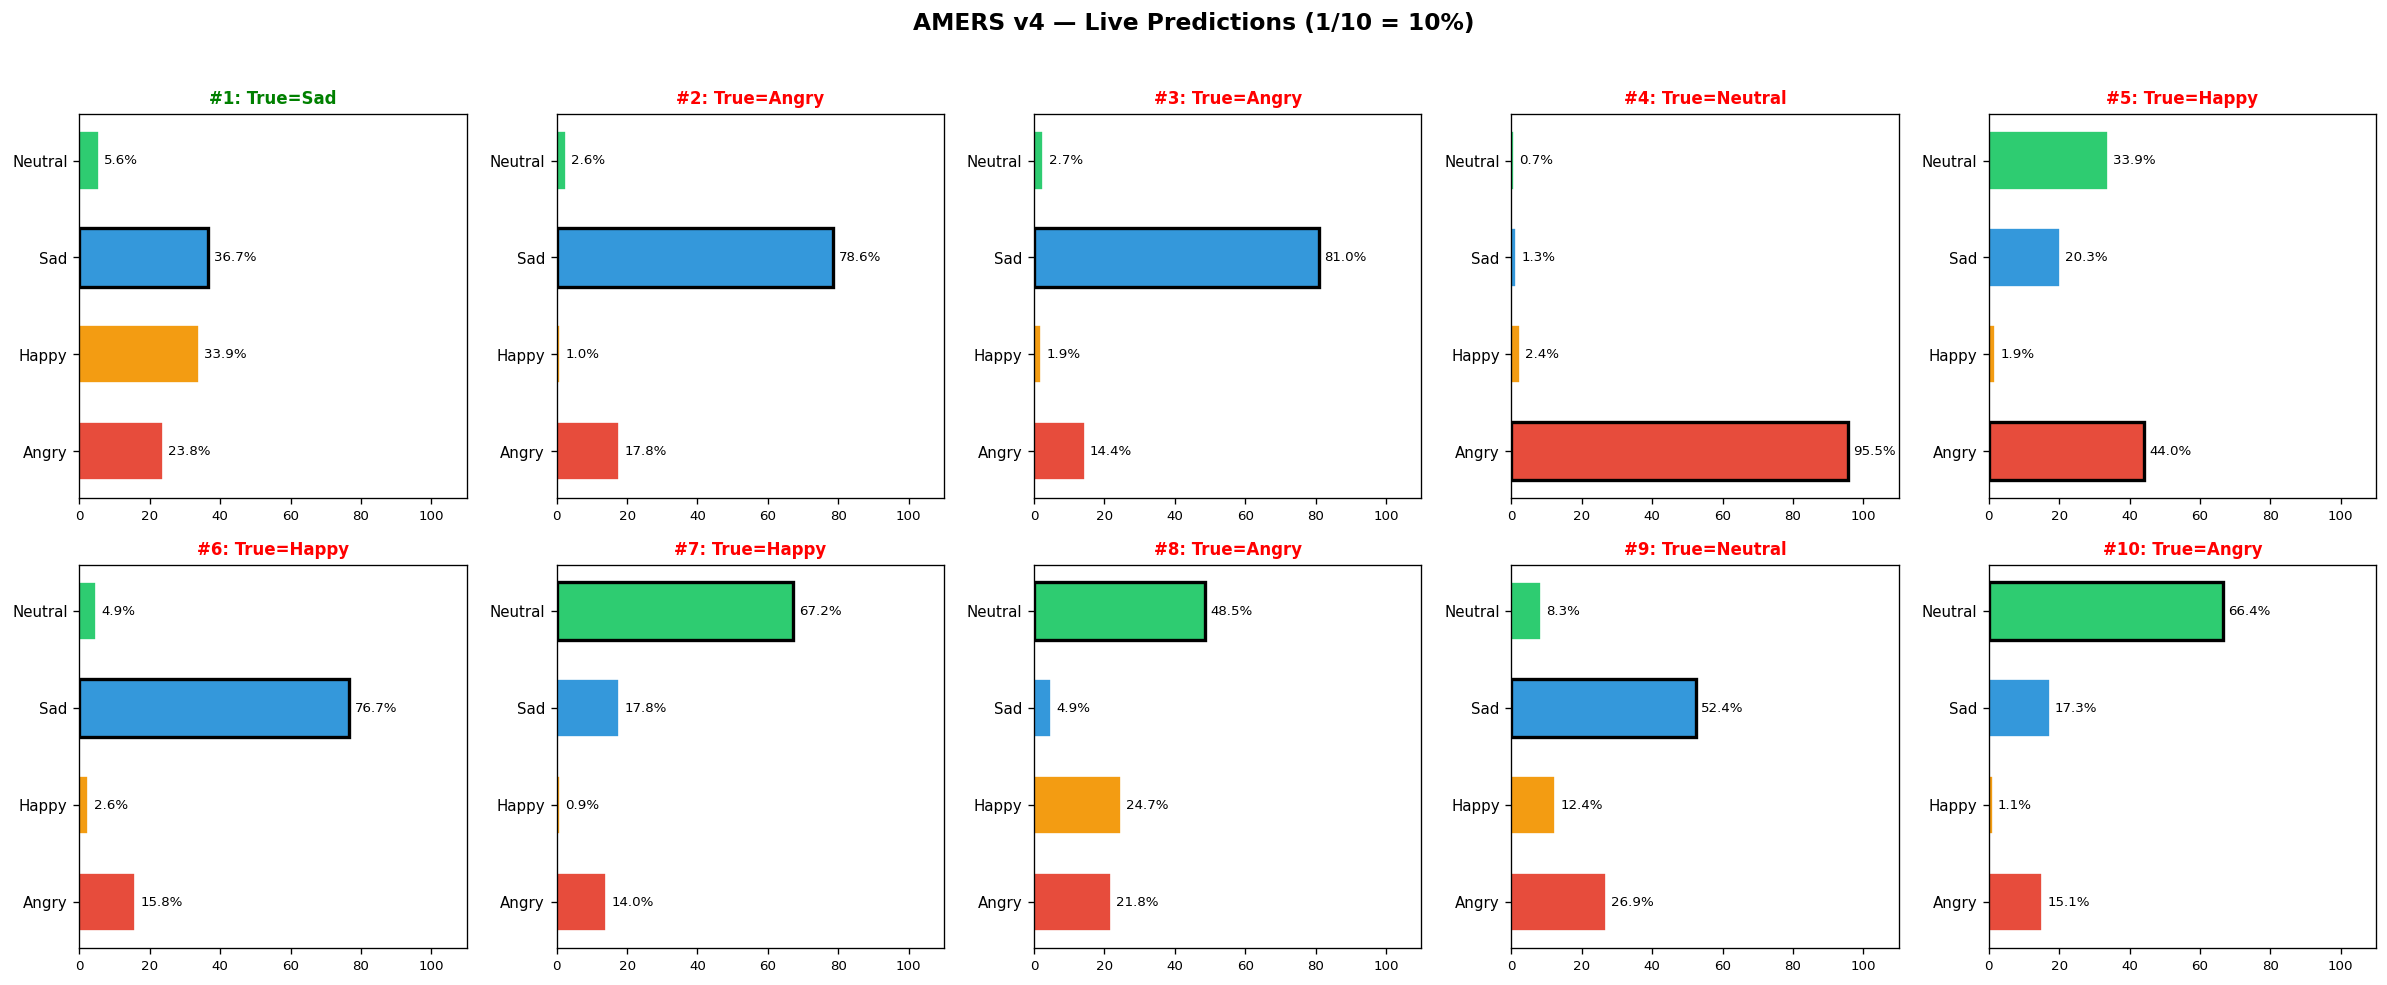


📁 Saved to: /content/outputs/v4_demo_predictions.png
   (also copied to Drive)


In [60]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  🎯 LIVE PREDICTIONS — Random test samples with confidence   ║
# ║  Re-run this cell to get different random samples!            ║
# ╚══════════════════════════════════════════════════════════════════╝
import random
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

N_SAMPLES = 10  # change this to show more/fewer samples
COLORS = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

total = len(test_labels)
indices = random.sample(range(total), min(N_SAMPLES, total))

print(f"{'='*70}")
print(f"  🎯 LIVE PREDICTIONS — {len(indices)} Random Test Samples")
print(f"{'='*70}\n")

correct = 0
rows = (len(indices) + 4) // 5
fig, axes = plt.subplots(rows, 5, figsize=(20, 4 * rows))
if rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

# Hide unused axes
for ax in axes[len(indices):]:
    ax.set_visible(False)

for idx_i, sample_idx in enumerate(indices):
    eeg_sample = test_eeg[sample_idx:sample_idx+1].to(device)
    sp_sample = test_sp[sample_idx:sample_idx+1].to(device)
    true_label = test_labels[sample_idx].item()

    with torch.no_grad():
        logits = fusion(eeg_sample, sp_sample)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred = int(logits.argmax(1).item())

    is_correct = pred == true_label
    correct += int(is_correct)
    status = '✅' if is_correct else '❌'

    print(f"  Sample {idx_i+1:2d} │ True: {LABEL_EMOJI[true_label]} {LABEL_NAMES[true_label]:8s} │ "
          f"Pred: {LABEL_EMOJI[pred]} {LABEL_NAMES[pred]:8s} │ "
          f"Conf: {probs[pred]*100:.1f}% │ {status}")

    # Bar chart
    ax = axes[idx_i]
    bars = ax.barh(LABEL_NAMES, probs * 100, color=COLORS, edgecolor='white', height=0.6)
    ax.set_xlim(0, 110)
    ax.set_title(f"#{idx_i+1}: True={LABEL_NAMES[true_label]}", fontsize=10,
                 fontweight='bold', color='green' if is_correct else 'red')
    bars[pred].set_edgecolor('black')
    bars[pred].set_linewidth(2)
    for i, v in enumerate(probs * 100):
        ax.text(v + 1.5, i, f"{v:.1f}%", va='center', fontsize=8)
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=8)

demo_acc = correct / len(indices) * 100
print(f"\n  ── Demo accuracy: {correct}/{len(indices)} = {demo_acc:.0f}% ──")

plt.suptitle(f"AMERS v4 — Live Predictions ({correct}/{len(indices)} = {demo_acc:.0f}%)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
_save_path = '/content/outputs/v4_demo_predictions.png'
os.makedirs(os.path.dirname(_save_path), exist_ok=True)
plt.savefig(_save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📁 Saved to: {_save_path}')
# Copy to Drive if mounted
if os.path.isdir('/content/drive/MyDrive/AMERS/outputs'):
    import shutil
    shutil.copy2(_save_path, '/content/drive/MyDrive/AMERS/outputs/')
    print('   (also copied to Drive)')

## 6. 📈 Full Test Set Evaluation

In [61]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  📈 FULL TEST SET — Accuracy, per-class, confidence, CM      ║
# ╚══════════════════════════════════════════════════════════════════╝
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score, cohen_kappa_score

total = len(test_labels)

with torch.no_grad():
    all_preds, all_probs = [], []
    for i in range(0, total, 512):
        end = min(i + 512, total)
        logits = fusion(test_eeg[i:end].to(device), test_sp[i:end].to(device))
        all_preds.append(logits.argmax(1).cpu())
        all_probs.append(torch.softmax(logits, dim=1).cpu())
    preds = torch.cat(all_preds).numpy()
    probs = torch.cat(all_probs).numpy()

labels = test_labels.numpy()
acc = (preds == labels).mean()
f1_mac = f1_score(labels, preds, average='macro', zero_division=0)
f1_wt = f1_score(labels, preds, average='weighted', zero_division=0)
kappa = cohen_kappa_score(labels, preds)

print(f"{'='*70}")
print(f"  📈 AMERS v4 — FULL TEST SET RESULTS ({total} samples)")
print(f"{'='*70}")
print(f"\n  Overall Accuracy:  {acc*100:.2f}%")
print(f"  Macro F1:          {f1_mac:.4f}")
print(f"  Weighted F1:       {f1_wt:.4f}")
print(f"  Cohen's Kappa:     {kappa:.4f}")

# Per-class
print(f"\n  {'─'*60}")
print(f"  Per-class breakdown:")
print(f"  {'─'*60}")
for c in range(4):
    mask = labels == c
    if mask.sum() == 0: continue
    cls_acc = (preds[mask] == c).mean()
    avg_conf = probs[mask, c].mean()
    print(f"    {LABEL_EMOJI[c]} {LABEL_NAMES[c]:8s} │ "
          f"Acc: {cls_acc*100:5.1f}% │ "
          f"Avg conf: {avg_conf*100:5.1f}% │ "
          f"n={mask.sum()}")

# Confidence analysis
pred_confs = probs[np.arange(len(preds)), preds]
correct_mask = preds == labels
print(f"\n  {'─'*60}")
print(f"  Confidence analysis:")
print(f"  {'─'*60}")
print(f"    When CORRECT:  avg conf = {pred_confs[correct_mask].mean()*100:.1f}%")
if (~correct_mask).sum() > 0:
    print(f"    When WRONG:    avg conf = {pred_confs[~correct_mask].mean()*100:.1f}%")
print(f"    Overall avg:   avg conf = {pred_confs.mean()*100:.1f}%")

# Classification report
print(f"\n  {'─'*60}")
print(f"  Classification Report:")
print(f"  {'─'*60}")
print(classification_report(labels, preds, target_names=LABEL_NAMES, digits=4))

# Confusion matrix
cm = confusion_matrix(labels, preds)
print(f"  Confusion Matrix (rows=true, cols=predicted):")
print(f"           {'  '.join(f'{n:>7s}' for n in LABEL_NAMES)}")
for i in range(4):
    row = '  '.join(f'{cm[i,j]:7d}' for j in range(4))
    print(f"    {LABEL_NAMES[i]:8s} {row}")

print(f"\n{'='*70}")
print(f"  🏆 Model is working! Accuracy: {acc*100:.2f}%, Macro F1: {f1_mac:.4f}")
print(f"{'='*70}")

  📈 AMERS v4 — FULL TEST SET RESULTS (1008 samples)

  Overall Accuracy:  26.29%
  Macro F1:          0.2627
  Weighted F1:       0.2623
  Cohen's Kappa:     0.0159

  ────────────────────────────────────────────────────────────
  Per-class breakdown:
  ────────────────────────────────────────────────────────────
    😠 Angry    │ Acc:  21.1% │ Avg conf:  33.3% │ n=228
    😊 Happy    │ Acc:  24.9% │ Avg conf:  18.6% │ n=217
    😢 Sad      │ Acc:  38.0% │ Avg conf:  32.0% │ n=221
    😐 Neutral  │ Acc:  23.1% │ Avg conf:  21.7% │ n=342

  ────────────────────────────────────────────────────────────
  Confidence analysis:
  ────────────────────────────────────────────────────────────
    When CORRECT:  avg conf = 66.6%
    When WRONG:    avg conf = 66.9%
    Overall avg:   avg conf = 66.8%

  ────────────────────────────────────────────────────────────
  Classification Report:
  ────────────────────────────────────────────────────────────
              precision    recall  f1-score   suppo

## 7. 📊 Visual Confusion Matrix & Confidence Distribution

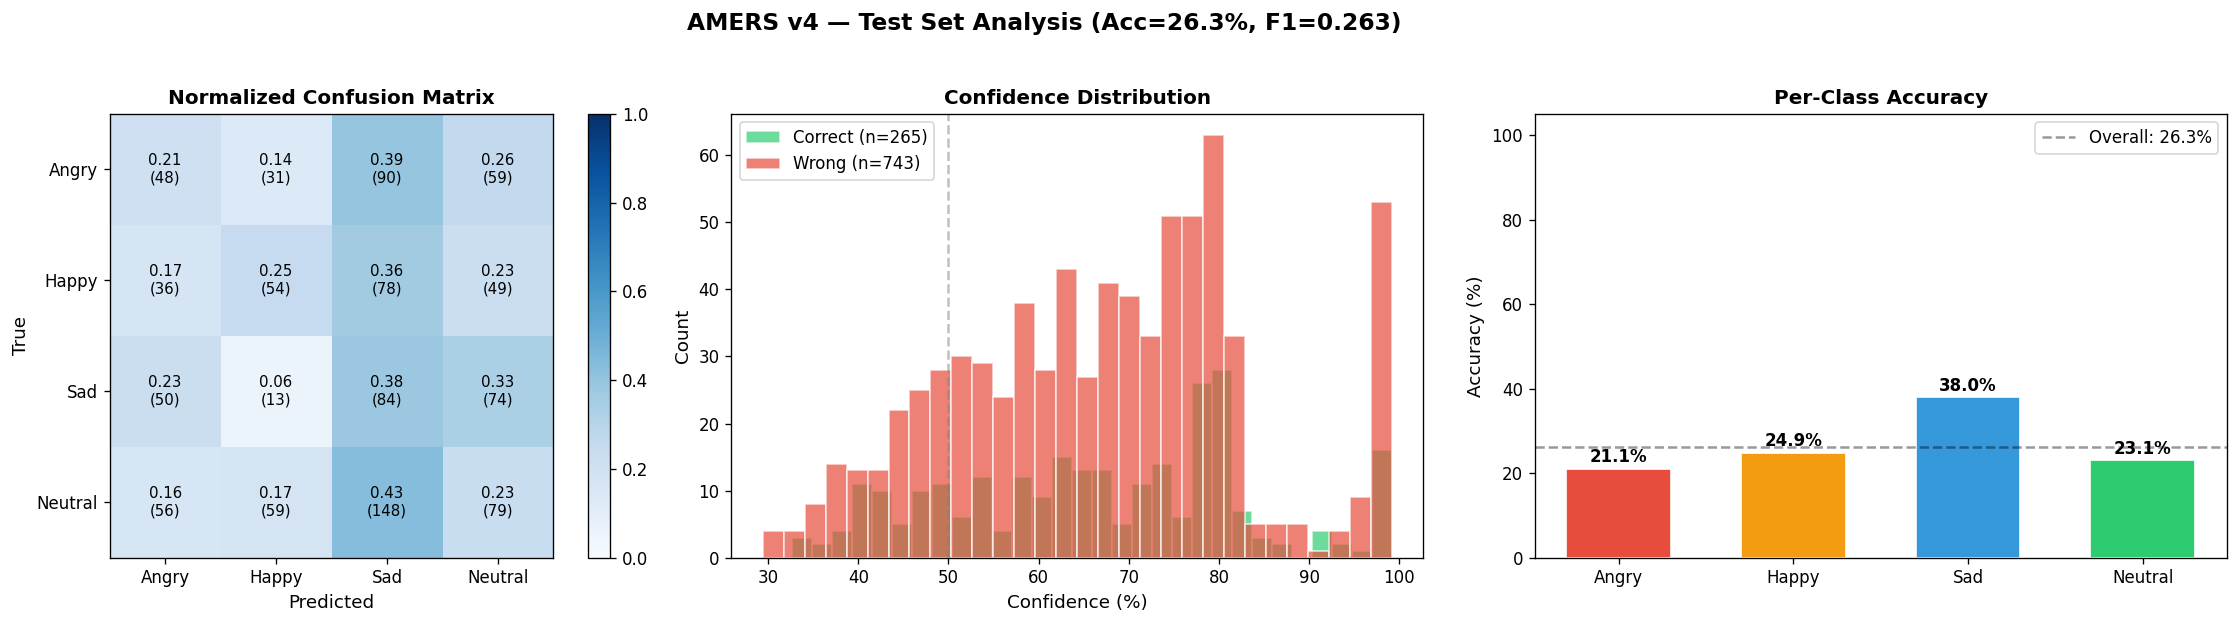

📁 Saved to: /content/outputs/v4_test_analysis.png
   (also copied to Drive)


In [62]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  📊 VISUAL PLOTS — Confusion matrix heatmap + confidence     ║
# ╚══════════════════════════════════════════════════════════════════╝
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── 1. Confusion Matrix Heatmap ──
ax = axes[0]
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(LABEL_NAMES, fontsize=10)
ax.set_yticks(range(4)); ax.set_yticklabels(LABEL_NAMES, fontsize=10)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
for i in range(4):
    for j in range(4):
        color = 'white' if cm_norm[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cm_norm[i,j]:.2f}\n({cm[i,j]})',
                ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im, ax=ax, fraction=0.046)

# ── 2. Confidence Distribution ──
ax = axes[1]
correct_confs = pred_confs[correct_mask]
wrong_confs = pred_confs[~correct_mask]
ax.hist(correct_confs * 100, bins=30, alpha=0.7, color='#2ecc71', label=f'Correct (n={len(correct_confs)})', edgecolor='white')
if len(wrong_confs) > 0:
    ax.hist(wrong_confs * 100, bins=30, alpha=0.7, color='#e74c3c', label=f'Wrong (n={len(wrong_confs)})', edgecolor='white')
ax.set_xlabel('Confidence (%)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Confidence Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)

# ── 3. Per-Class Accuracy Bar Chart ──
ax = axes[2]
cls_accs = []
for c in range(4):
    mask = labels == c
    cls_accs.append((preds[mask] == c).mean() * 100 if mask.sum() > 0 else 0)
bars = ax.bar(LABEL_NAMES, cls_accs, color=COLORS, edgecolor='white', width=0.6)
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy', fontsize=12, fontweight='bold')
for bar, v in zip(bars, cls_accs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f'{v:.1f}%',
            ha='center', fontsize=10, fontweight='bold')
ax.axhline(y=acc*100, color='black', linestyle='--', alpha=0.4, label=f'Overall: {acc*100:.1f}%')
ax.legend(fontsize=10)

plt.suptitle(f'AMERS v4 — Test Set Analysis (Acc={acc*100:.1f}%, F1={f1_mac:.3f})',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
_save_path = '/content/outputs/v4_test_analysis.png'
os.makedirs(os.path.dirname(_save_path), exist_ok=True)
plt.savefig(_save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'📁 Saved to: {_save_path}')
# Copy to Drive if mounted
if os.path.isdir('/content/drive/MyDrive/AMERS/outputs'):

    import shutil    
    print('   (also copied to Drive)')
    shutil.copy2(_save_path, '/content/drive/MyDrive/AMERS/outputs/')

## 8. 🔬 Single Sample Deep Dive
Change `SAMPLE_INDEX` below to inspect any specific test sample in detail.

In [63]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  🔬 SINGLE SAMPLE DEEP DIVE — inspect one prediction         ║
# ║  Change SAMPLE_INDEX to look at different samples             ║
# ╚══════════════════════════════════════════════════════════════════╝
import random

SAMPLE_INDEX = random.randint(0, len(test_labels) - 1)  # or set manually: e.g., 42

eeg_sample = test_eeg[SAMPLE_INDEX:SAMPLE_INDEX+1].to(device)
sp_sample = test_sp[SAMPLE_INDEX:SAMPLE_INDEX+1].to(device)
true_label = test_labels[SAMPLE_INDEX].item()

with torch.no_grad():
    logits = fusion(eeg_sample, sp_sample)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred = int(logits.argmax(1).item())

is_correct = pred == true_label

print(f"{'='*50}")
print(f"  🔬 Single Sample Deep Dive — #{SAMPLE_INDEX}")
print(f"{'='*50}")
print(f"\n  True emotion:      {LABEL_EMOJI[true_label]} {LABEL_NAMES[true_label]}")
print(f"  Predicted emotion: {LABEL_EMOJI[pred]} {LABEL_NAMES[pred]}")
print(f"  Result:            {'✅ CORRECT' if is_correct else '❌ WRONG'}")
print(f"\n  Confidence scores:")
for c in range(4):
    bar = '█' * int(probs[c] * 40)
    marker = ' ◄── PRED' if c == pred else (' ◄── TRUE' if c == true_label and not is_correct else '')
    print(f"    {LABEL_EMOJI[c]} {LABEL_NAMES[c]:8s} {probs[c]*100:5.1f}% {bar}{marker}")

# Logits (raw)
logits_np = logits.cpu().numpy()[0]
print(f"\n  Raw logits: {', '.join(f'{v:.3f}' for v in logits_np)}")

# EEG embedding stats
eeg_np = eeg_sample.cpu().numpy()[0]
sp_np = sp_sample.cpu().numpy()[0]
print(f"\n  EEG embedding:    mean={eeg_np.mean():.4f}, std={eeg_np.std():.4f}, "
      f"min={eeg_np.min():.4f}, max={eeg_np.max():.4f}")
print(f"  Speech embedding: mean={sp_np.mean():.4f}, std={sp_np.std():.4f}, "
      f"min={sp_np.min():.4f}, max={sp_np.max():.4f}")
print(f"{'='*50}")

  🔬 Single Sample Deep Dive — #692

  True emotion:      😐 Neutral
  Predicted emotion: 😐 Neutral
  Result:            ✅ CORRECT

  Confidence scores:
    😠 Angry     15.0% ██████
    😊 Happy      3.5% █
    😢 Sad        2.2% 
    😐 Neutral   79.2% ███████████████████████████████ ◄── PRED

  Raw logits: 0.246, -1.214, -1.662, 1.909

  EEG embedding:    mean=-0.1578, std=1.9506, min=-6.1147, max=4.6296
  Speech embedding: mean=-0.3515, std=2.5995, min=-5.8126, max=8.2567
